<a href="https://colab.research.google.com/github/kasulavasanth58807131-byte/Trader-Performance-and-Sentiment-Analysis/blob/main/fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
ds=pd.read_csv("/content/Fraud.csv")

In [4]:
ds.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [5]:
ds.shape

(1927241, 11)

In [6]:
ds['type'].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [7]:
ds.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,1
isFraud,1


In [8]:
ds['isFraud'].value_counts()

,count
isFraud,
0.0,1925338
1.0,1902


In [9]:
ds['isFlaggedFraud'].value_counts()

,count
isFlaggedFraud,
0.0,1927240


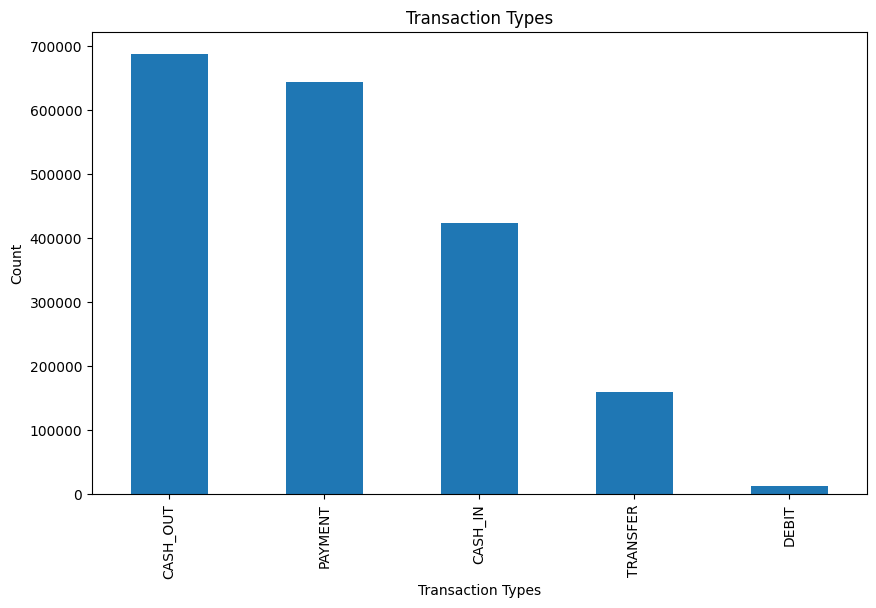

In [10]:
plt.figure(figsize=(10,6))
ds['type'].value_counts().plot(kind='bar', title='Transaction Types')
plt.xlabel('Transaction Types')
plt.ylabel('Count')
plt.show()

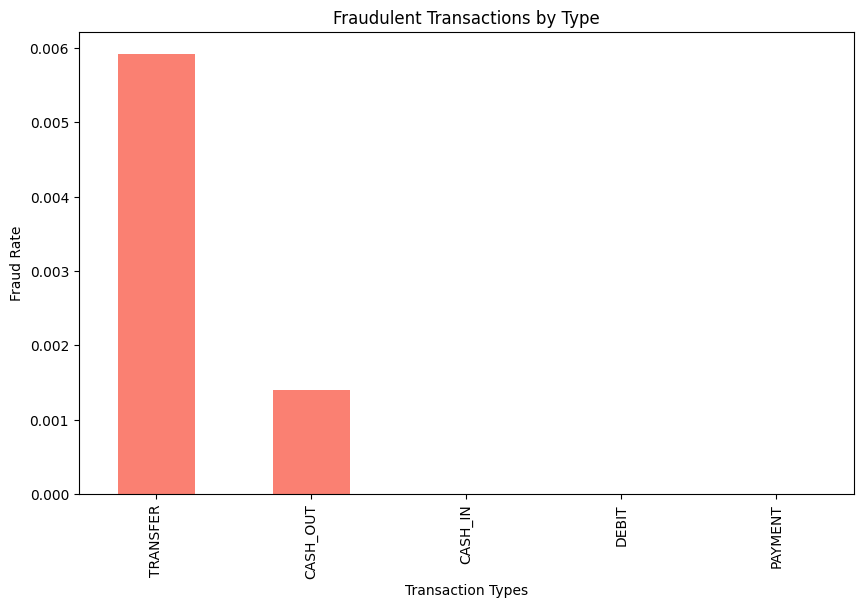

In [11]:
plt.figure(figsize=(10,6))
fraud_by_type = ds.groupby('type')['isFraud'].mean().sort_values(ascending=False)
fraud_by_type.plot(kind='bar', title='Fraudulent Transactions by Type', color=['salmon'])
plt.xlabel('Transaction Types')
plt.ylabel('Fraud Rate')
plt.show()

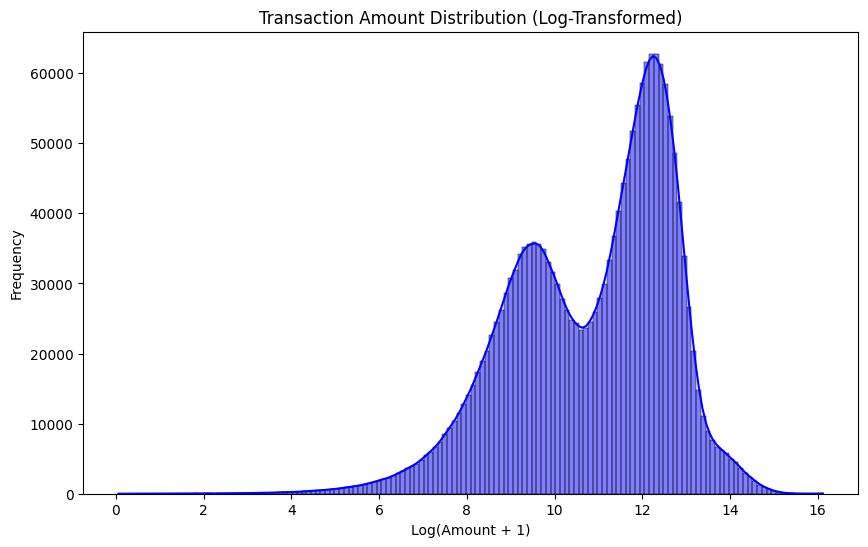

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(ds['amount']), bins=150, kde=True, color = 'blue')
plt.title('Transaction Amount Distribution (Log-Transformed)')
plt.xlabel('Log(Amount + 1)')
plt.ylabel('Frequency')
plt.show()

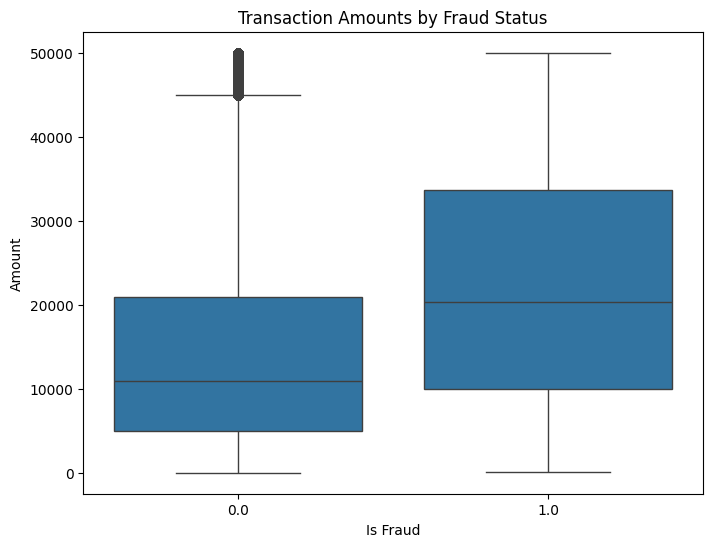

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='isFraud', y='amount', data=ds[ds['amount'] < 50000])
plt.title('Transaction Amounts by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Amount')
plt.show()

In [30]:
ds['balanceDiffOriginal'] = ds['oldbalanceOrg'] - ds['newbalanceOrig']
ds['balanceDiffDest'] = ds['oldbalanceDest'] - ds['newbalanceDest']
(ds['balanceDiffOriginal'] < 0).sum(), (ds['balanceDiffDest'] < 0).sum()

(np.int64(423423), np.int64(858515))

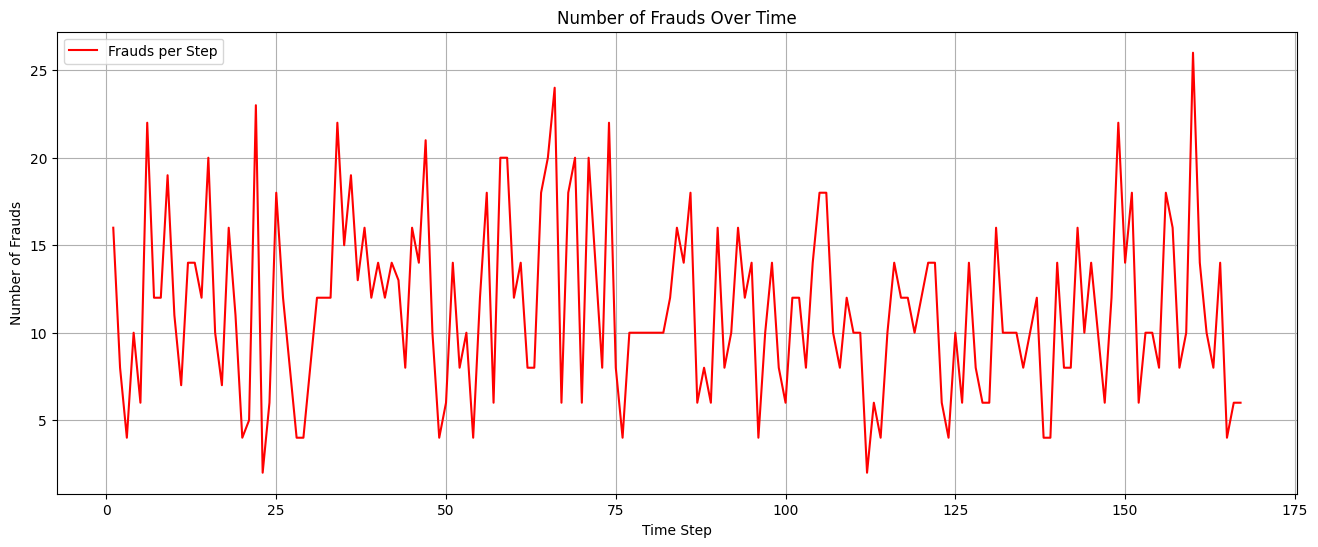

In [16]:
frauds_per_step = ds[ds['isFraud'] == 1]['step'].value_counts().sort_index()
plt.figure(figsize=(16,6))
plt.plot(frauds_per_step.index, frauds_per_step.values, label = "Frauds per Step", color='red')
plt.title('Number of Frauds Over Time')
plt.xlabel('Time Step')
plt.ylabel('Number of Frauds')
plt.grid(True)
plt.legend()
plt.show()

In [18]:
ds.drop(columns='step', inplace=False)
top_senders = ds['nameOrig'].value_counts().head(10)
top_receivers = ds['nameDest'].value_counts().head(10)
top_senders
top_receivers
fraud_users = ds[ds['isFraud'] == 1]['nameOrig'].value_counts().head(10)
fraud_users
fraud_types = ds[ds['type'].isin(['TRANSFER', 'CASH_OUT'])]
fraud_types['type'].value_counts()

,count
type,
CASH_OUT,687639
TRANSFER,159360


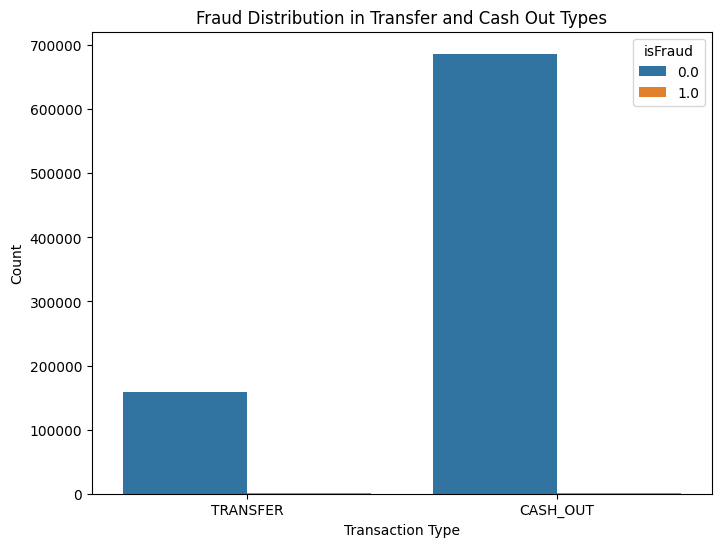

In [19]:
plt.figure(figsize=(8, 6))
sns.countplot(data = fraud_types, x='type', hue='isFraud')
plt.title('Fraud Distribution in Transfer and Cash Out Types')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

In [21]:
corr = ds[['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','isFraud']].corr()
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,0.002381,-0.002909,0.217354,0.312613,0.131111
oldbalanceOrg,0.002381,1.000000,0.999040,0.093303,0.063865,0.005082
newbalanceOrig,-0.002909,0.999040,1.000000,0.095292,0.063654,-0.008673
oldbalanceDest,0.217354,0.093303,0.095292,1.000000,0.983670,-0.006799
newbalanceDest,0.312613,0.063865,0.063654,0.983670,1.000000,0.000496
isFraud,0.131111,0.005082,-0.008673,-0.006799,0.000496,1.000000


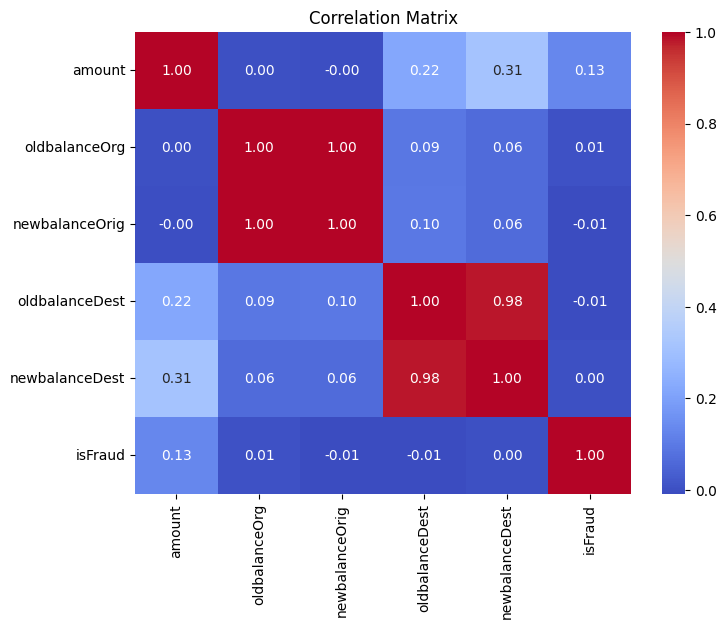

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [24]:
zero_post_transactions = ds[
    (ds['oldbalanceOrg'] > 0) &
    (ds['newbalanceOrig'] == 0) &
    (ds['type'].isin(['TRANSFER', 'CASH_OUT']))]
len(zero_post_transactions)

358798

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [28]:
ds_model = ds.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)
ds_model.head()
categorical_features = ['type']
numerical_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
y = ds_model['isFraud']
X = ds_model.drop('isFraud', axis=1)


In [31]:
# Check NaNs
print(ds_model.isnull().sum())
print(f"Shape before drop: {ds_model.shape}")

# Drop rows with any NaN
ds_model = ds_model.dropna()

print(f"Shape after drop: {ds_model.shape}")

# Re-define X and y after dropna
y = ds_model['isFraud']
X = ds_model.drop('isFraud', axis=1)

step                   0
type                   0
amount                 0
oldbalanceOrg          0
newbalanceOrig         0
oldbalanceDest         0
newbalanceDest         1
isFraud                1
balanceDiffOriginal    0
balanceDiffDest        1
dtype: int64
Shape before drop: (1927241, 10)
Shape after drop: (1927240, 10)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='drop'
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

pipeline.fit(X_train, y_train)

# Predicting on the test set
y_pred = pipeline.predict(X_test)

In [34]:
print(classification_report(y_test, y_pred))
pipeline.score(X_test, y_test)*100

              precision    recall  f1-score   support

         0.0       1.00      0.94      0.97    577601
         1.0       0.02      0.96      0.03       571

    accuracy                           0.94    578172
   macro avg       0.51      0.95      0.50    578172
weighted avg       1.00      0.94      0.97    578172



94.37364659651453

In [35]:
confusion_matrix(y_test, y_pred)

array([[545094,  32507],
       [    23,    548]])

In [36]:
y_prob = pipeline.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC Score: {roc_auc:.4f}')
import joblib
joblib.dump(pipeline, 'fraud_detection_model.pkl')

ROC-AUC Score: 0.9883


['fraud_detection_model.pkl']